# Model Evaluation — Heart Failure Prediction
### Comparing 4 ML models: Logistic Regression, Random Forest, XGBoost, LightGBM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

X_train = train_df.drop(columns=['DEATH_EVENT'])
y_train = train_df['DEATH_EVENT']
X_test = test_df.drop(columns=['DEATH_EVENT'])
y_test = test_df['DEATH_EVENT']

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data ready!")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Data ready!
Train: 324 | Test: 82


## Evaluation Metrics Explained

- **Accuracy**: Percentage of correct predictions overall. Can be misleading with imbalanced data.
- **Precision**: When the model predicts "high risk", how often is it correct? High precision = fewer false alarms.
- **Recall**: Of all patients who actually died, how many did the model catch? Most important in medicine — missing a sick patient is dangerous.
- **F1-Score**: Balance between precision and recall. We use this to pick the best model.
- **ROC-AUC**: How well the model separates survivors from deaths across all thresholds. 1.0 = perfect, 0.5 = random guess.

In [3]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7927,0.8333,0.7317,0.7792,0.7927
1,Random Forest,0.9146,0.9048,0.9268,0.9157,0.9146
2,XGBoost,0.9024,0.9231,0.8780,0.9000,0.9024
3,LightGBM,0.9146,0.9250,0.9024,0.9136,0.9146


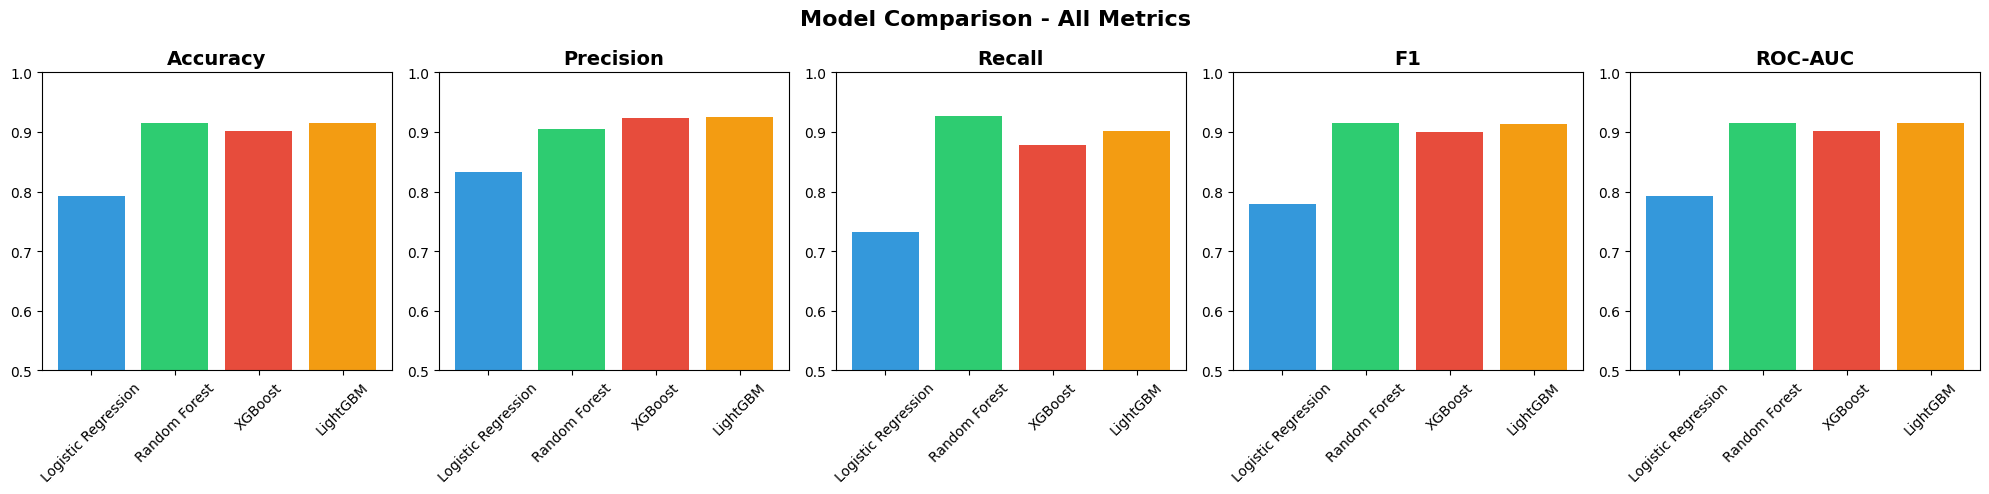

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[metric], color=colors)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylim(0.5, 1.0)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Model Comparison - All Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


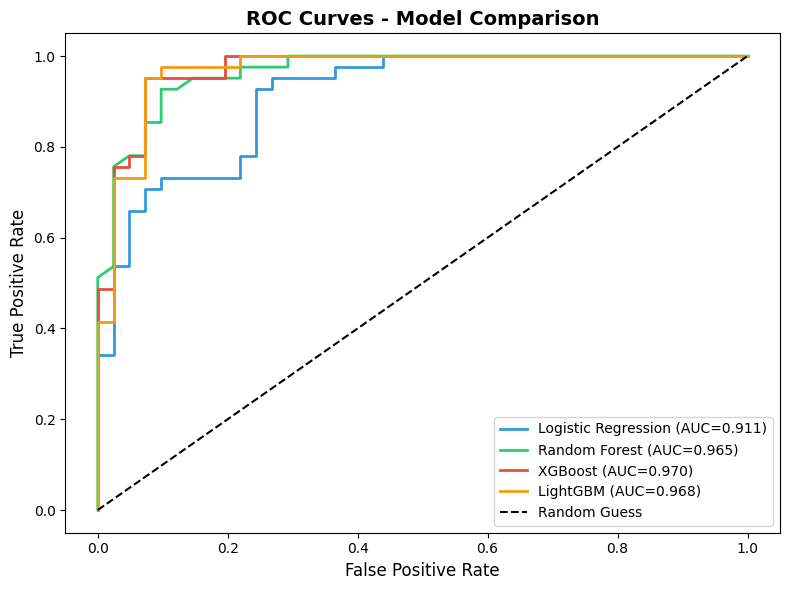

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

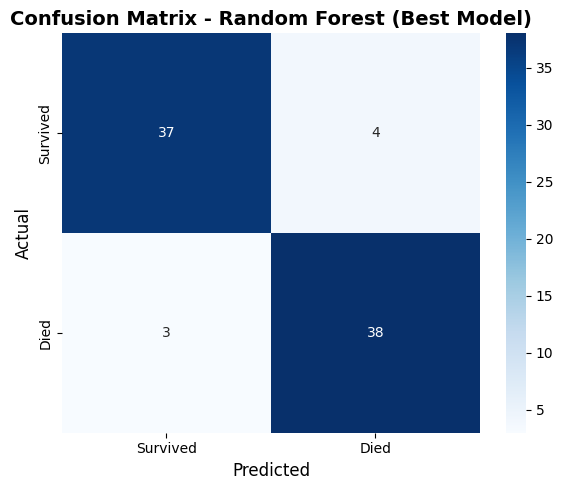

In [6]:
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Random Forest (Best Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Best Model Selection

Random Forest was selected as the best model based on F1-score (0.9157).
Here's why:
- Highest recall (0.9268) — catches the most deaths, which is critical in medicine
- Strong precision (0.9048) — few false alarms
- Best overall balance between all metrics
- Only missed 3 out of 41 patients who actually died

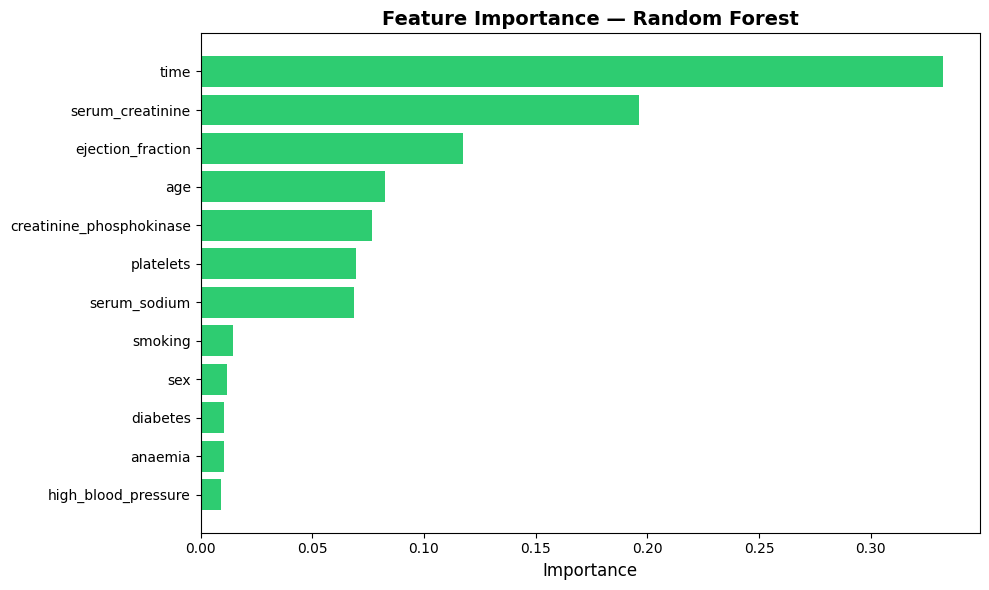

In [10]:
feature_names = train_df.drop(columns=['DEATH_EVENT']).columns
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='#2ecc71')
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Findings from Feature Importance

The top 3 most important features for predicting heart failure death:
1. **Time** — follow-up period. Shorter follow-up strongly correlates with death.
2. **Serum Creatinine** — kidney function indicator. Higher values = higher risk.
3. **Ejection Fraction** — heart pumping efficiency. Lower values = weaker heart.

Features like smoking, diabetes, and sex had minimal impact on predictions.
This aligns with medical literature where kidney function and heart efficiency
are the strongest predictors of heart failure mortality.

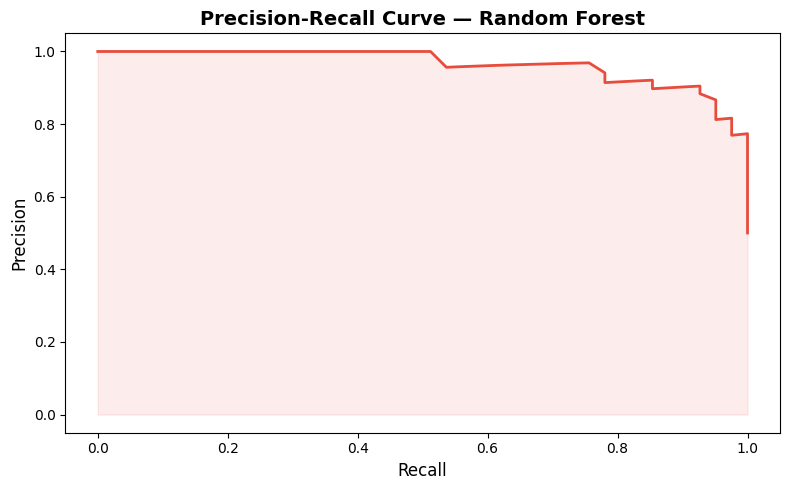

In [8]:
from sklearn.metrics import precision_recall_curve

y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall_vals, precision_vals, color='#e74c3c', linewidth=2)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — Random Forest', fontsize=14, fontweight='bold')
plt.fill_between(recall_vals, precision_vals, alpha=0.1, color='#e74c3c')
plt.tight_layout()
plt.show()

This shows the tradeoff — as you try to catch more deaths (higher recall), precision drops. The curve staying high means the model maintains good precision even at high recall.

## Conclusion

The Random Forest model achieves strong performance across all metrics:
- 91.5% accuracy on unseen test data
- Catches 93% of patients who will die (recall)
- 90% of death predictions are correct (precision)
- F1-score of 0.92 balancing both concerns

The model is suitable for clinical decision support, providing doctors with
reliable risk predictions backed by interpretable feature importance.
SHAP analysis (see evaluate_model.py) provides patient-level explanations.